# Veri Seti İlk İşlemler ve Görselleştirme
* Veri Seti Oluşturma
* Veri Seti İnceleme
* Veri Setinin Temel İstatistiksel Özellikleri
* Görselleştirme
* Matplotlib kütüphanesi
* Seaborn kütüphanesi


## Veri Seti Oluşturma
*  Örnek veri seti oluştur: hem kategorik hem de sayısal (int,float) gibi değerler olsun.
* Müşteri Bilgileri:
* musteri_id: benzersin kimlik(int)
* cinsiyet: kategorik
* yas: int
* gelir: float
* sehir: kategorik
* alisveris_sayisi: int
* memnuniyet: float(1-5)


In [39]:
import pandas as pd
import numpy as np

# örnek veri seti oluşturalım
np.random.seed(42)
veri = pd.DataFrame({
    "musteri_id" : range(1,21),
    "cinsiyet" : np.random.choice(["erkek","kadın"],20),
    "yas" : np.random.randint(18,60,20),
    "gelir" : np.random.uniform(3000,15000,20).round(2),
    "sehir" : np.random.choice(["İstanbul","Ankara","İzmir","Konya"],20),
    "alisveris_sayisi" : np.random.randint(1,20,20),
    "memnuniyet" : np.random.uniform(1,5,20).round(1)
})
veri

,musteri_id,cinsiyet,yas,gelir,sehir,alisveris_sayisi,memnuniyet
0,1,erkek,39,8405.99,Konya,15,2.4
1,2,kadın,19,3159.18,Ankara,13,1.5
2,3,erkek,41,14306.42,Ankara,9,4.5
3,4,erkek,47,9759.46,Ankara,15,3.5
4,5,erkek,55,7625.00,Konya,13,2.3
5,6,kadın,19,3191.60,Ankara,1,1.3
6,7,erkek,38,5770.73,İzmir,7,2.2
7,8,erkek,50,5892.31,Konya,9,2.3
8,9,erkek,29,11199.16,İzmir,1,3.9
9,10,kadın,39,10319.96,Konya,12,3.6


## Veri Seti İnceleme
Bu bölüme, bir veri setini analiz etmeden önce onu tanımayı, yapısını anlamayı ve temel özet bilgilerini çıkarmayı öğreneceğiz. Veriyi iyi tanımak doğru analiz ve modelleme adımlarının temelidir. Bu nedenle veri setinin özelliklerini, eksikliklerini, türlerini ve dağılımını anlamak çok önemlidir.
Bu bölümde neler öğreneceğiz?
* Veri setinin genel görünümü
* Veri tipleri, eksik değerler ve bellek kullanımı
* Sayısal ve kategorik değişkenleri ayırma işlemi
* Temel istatistiksel özetleri elde etme
* Eksik ve tekrar eden verileri kontrol etme
* Korelasyon ve temel ilişkileri gözlemleme
* İlk görselleştirmeler ile genel dağılımı görme

### Veri Setinin Genel Görünümü

In [40]:
# verinin ilk 5 satırını yazdır
veri.head()

,musteri_id,cinsiyet,yas,gelir,sehir,alisveris_sayisi,memnuniyet
0,1,erkek,39,8405.99,Konya,15,2.4
1,2,kadın,19,3159.18,Ankara,13,1.5
2,3,erkek,41,14306.42,Ankara,9,4.5
3,4,erkek,47,9759.46,Ankara,15,3.5
4,5,erkek,55,7625.00,Konya,13,2.3


In [41]:
#veri tipi ,eksik değer ve sütun bilgileri
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   musteri_id        20 non-null     int64  
 1   cinsiyet          20 non-null     object 
 2   yas               20 non-null     int64  
 3   gelir             20 non-null     float64
 4   sehir             20 non-null     object 
 5   alisveris_sayisi  20 non-null     int64  
 6   memnuniyet        20 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ KB


In [42]:
# temel istatistiksel bilgiler
veri.describe()

,musteri_id,yas,gelir,alisveris_sayisi,memnuniyet
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,38.350000,8127.259000,9.000000,3.020000
std,5.91608,11.930831,3475.508974,5.467608,0.985473
min,1.00000,19.000000,3159.180000,1.000000,1.300000
25%,5.75000,31.250000,5418.182500,4.500000,2.300000
50%,10.50000,39.000000,7897.300000,9.000000,3.050000
75%,15.25000,45.500000,10539.760000,13.000000,3.900000
max,20.00000,59.000000,14306.420000,19.000000,4.500000


In [43]:
#veri setinin genel boyutu
veri.shape

(20, 7)

### Veri Tipleri ve Değişken Türleri

In [44]:
#veri tipleri
veri.dtypes

,0
musteri_id,int64
cinsiyet,object
yas,int64
gelir,float64
sehir,object
alisveris_sayisi,int64
memnuniyet,float64


In [45]:
#sayısal verileri bul
veri.select_dtypes(include= ["int64","float64"]).columns.tolist()

['musteri_id', 'yas', 'gelir', 'alisveris_sayisi', 'memnuniyet']

In [46]:
#kategorik verileri bul
veri.select_dtypes(include=["object"]).columns.tolist()

['cinsiyet', 'sehir']

### Eksik Değer ve Tekrarlanan Satır Kontrolü

In [47]:
#eksik değer analizi
veri.isnull().sum()

,0
musteri_id,0
cinsiyet,0
yas,0
gelir,0
sehir,0
alisveris_sayisi,0
memnuniyet,0


In [48]:
#tekrarlanan satır kontrolü
veri.duplicated().sum()

np.int64(0)

### Kategorik ve Sayısal Değer Dağılımı

In [49]:
# kategorik değerlerin benzersiz değerleri
for sutun in ["cinsiyet","sehir"]:
  print(veri[sutun].unique())

['erkek' 'kadın']
['Konya' 'Ankara' 'İzmir' 'İstanbul']


In [50]:
# kategorik değişkenlerin freakans dağılımı
for sutun in ["cinsiyet","sehir"]:
  print(veri[sutun].value_counts())

cinsiyet
erkek    13
kadın     7
Name: count, dtype: int64
sehir
Konya       7
Ankara      7
İzmir       3
İstanbul    3
Name: count, dtype: int64


In [51]:
#sayısal değerlerin aralıkları
for sutun in ["yas","gelir","alisveris_sayisi","memnuniyet"]:
  print(f"{sutun}: {veri[sutun].min()} - {veri[sutun].max()}")

yas: 19 - 59
gelir: 3159.18 - 14306.42
alisveris_sayisi: 1 - 19
memnuniyet: 1.3 - 4.5


### Korelasyon Analizi

In [52]:
veri.corr(numeric_only=True)

,musteri_id,yas,gelir,alisveris_sayisi,memnuniyet
musteri_id,1.000000,-0.027962,0.056956,-0.331929,0.262700
yas,-0.027962,1.000000,0.321997,0.508299,-0.026590
gelir,0.056956,0.321997,1.000000,-0.001485,0.588952
alisveris_sayisi,-0.331929,0.508299,-0.001485,1.000000,-0.181684
memnuniyet,0.262700,-0.026590,0.588952,-0.181684,1.000000


### Basit Görsel İnceleme

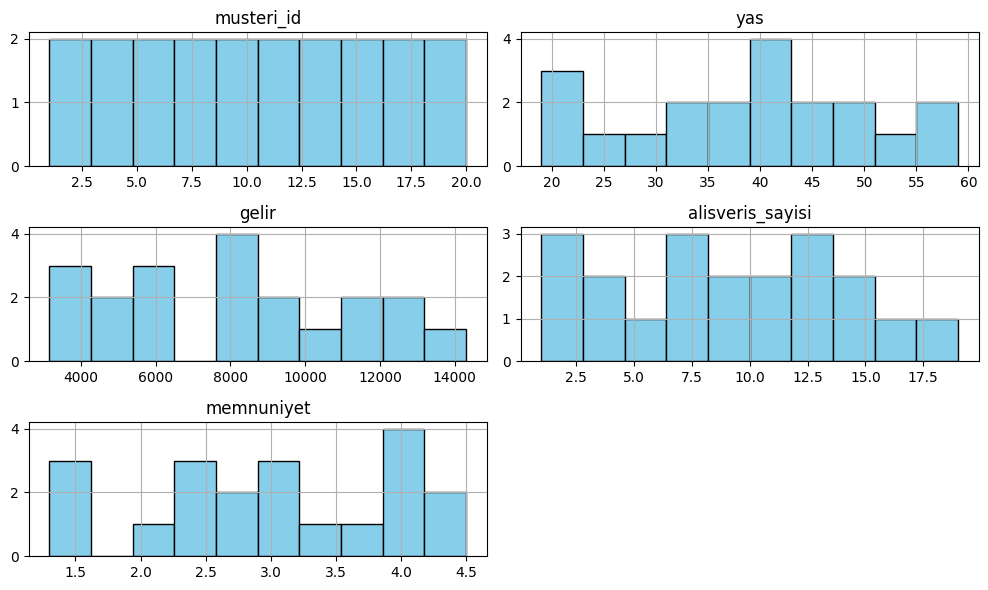

In [53]:
import matplotlib.pyplot as plt

veri.hist(figsize=(10,6), bins=10,color="skyblue",edgecolor="black")
plt.tight_layout()
plt.show()

Bu adımda neleri öğrendik?
* Veri setimizin yapısını, türlerini ve boyutunu
* Eksik veya tekrarlayan kayıt olup olmadığını
* Sayısal değişkenlerin temel istatistiksel yorumlanması
* Kategorik değişkenlerin dağılımları
* İlk görselleştirme

## Temel İstatistiksel Özellikler
Bu bölümde amacımız veri setindeki sayısal değişkenleri daha derinlemesine analiz etmek ve verinin genel istatistiksel yapısını anlamaktır. Yani veri ne kadar ortalama etrafında yoğunlaşmış?, değerler arasında nasıl bir ilişki var, dağılım dengeli mi? gibi soruları cevaplamaya çalışalım.

* Ortalama medyan ve mod
* Varyans ve std inceleme
* Minimum, maksimum ve çeyrek değerleri (quantile)
* Değişkenler arası korelasyon


### Ortalama,Medyan ve Mod

In [54]:
#mean(ortalama)
veri[["yas","gelir","alisveris_sayisi","memnuniyet"]].mean()

,0
yas,38.350
gelir,8127.259
alisveris_sayisi,9.000
memnuniyet,3.020


In [55]:
#medyan
veri[["yas","gelir","alisveris_sayisi","memnuniyet"]].median()

,0
yas,39.00
gelir,7897.30
alisveris_sayisi,9.00
memnuniyet,3.05


In [56]:
#mod: en sık görülen değee
veri[["yas"]].mode()

,yas
0,19
1,38
2,39


In [57]:
veri[["alisveris_sayisi"]].mode()

,alisveris_sayisi
0,1


### Dağılım Ölçüleri- Varyans,std,min,max

In [58]:
#varyans
veri[["yas","gelir","alisveris_sayisi","memnuniyet"]].var()

,0
yas,1.423447e+02
gelir,1.207916e+07
alisveris_sayisi,2.989474e+01
memnuniyet,9.711579e-01


In [59]:
#std
veri[["yas","gelir","alisveris_sayisi","memnuniyet"]].std()

,0
yas,11.930831
gelir,3475.508974
alisveris_sayisi,5.467608
memnuniyet,0.985473


In [60]:
#minimum, maksimum ve çeyrek bilgileri
veri[["yas","gelir","alisveris_sayisi","memnuniyet"]].quantile([0,0.25,0.5,0.75,1])

,yas,gelir,alisveris_sayisi,memnuniyet
0.00,19.00,3159.1800,1.0,1.30
0.25,31.25,5418.1825,4.5,2.30
0.50,39.00,7897.3000,9.0,3.05
0.75,45.50,10539.7600,13.0,3.90
1.00,59.00,14306.4200,19.0,4.50


## Korelasyon Analizi
* Korelasyon 1'e yaklaştıkça pozitif ilişki
* -1 yaklaştıkça negatif ilişki
* 0 a yakınsa ilişki zayıf veya yoktur

In [61]:
veri.corr(numeric_only=True)

,musteri_id,yas,gelir,alisveris_sayisi,memnuniyet
musteri_id,1.000000,-0.027962,0.056956,-0.331929,0.262700
yas,-0.027962,1.000000,0.321997,0.508299,-0.026590
gelir,0.056956,0.321997,1.000000,-0.001485,0.588952
alisveris_sayisi,-0.331929,0.508299,-0.001485,1.000000,-0.181684
memnuniyet,0.262700,-0.026590,0.588952,-0.181684,1.000000


## Görselleştirme: Matplotlib
* Matplotlib kütüphanesi temel yapısı
* Çizgi grafik (line plot)
* Scatter plot (saçılım grafiği)
* Sütun (bar plot) ve yatay sütun grafikleri
* Pasta grafiği (pie chart)
* Histogram
* Kutu grafiği (boxplot)
* Çoklu grafik (subplot) oluşturma

### Çizgi grafik
Zaman serileri veya ardışık değişkenler

In [62]:
import matplotlib.pyplot as plt

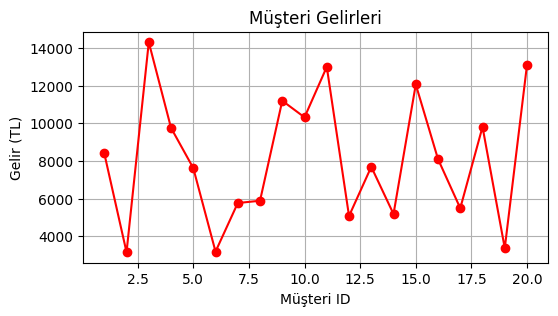

In [63]:
#line plot
plt.figure(figsize=(6,3))
plt.plot(veri["musteri_id"],veri["gelir"],marker="o",color="red")
plt.title("Müşteri Gelirleri")
plt.xlabel("Müşteri ID")
plt.ylabel("Gelir (TL)")
plt.grid()
plt.show()

### Scatter Plot (Saçılım Grafiği)
Değişkenler arasındaki korelasyonu tespit etmek için kullanılır

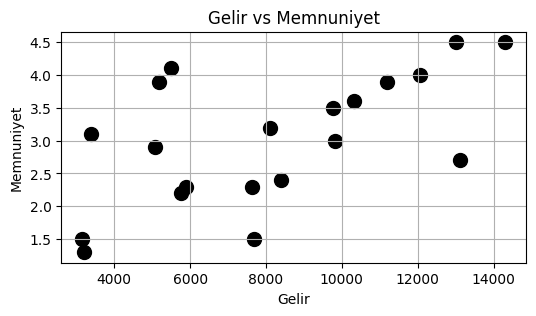

In [64]:
plt.figure(figsize=(6,3))
plt.scatter(veri["gelir"],veri["memnuniyet"],s=100,color="black")
plt.xlabel("Gelir")
plt.ylabel("Memnuniyet")
plt.title("Gelir vs Memnuniyet")
plt.grid(True)
plt.show()

### Bar plot (Sütun Grafiği)
Kategorik değişkenlerin karşılaştırılması

In [65]:
sehir_sayilari = veri["sehir"].value_counts()
sehir_sayilari

,count
sehir,
Konya,7
Ankara,7
İzmir,3
İstanbul,3


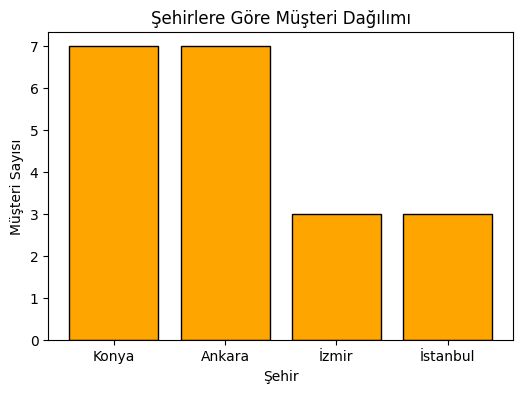

In [66]:
#Her şehirde kaç müşteri olduğu analizi
plt.figure(figsize=(6,4))
plt.bar(sehir_sayilari.index,sehir_sayilari.values,color="orange",edgecolor="black")
plt.title("Şehirlere Göre Müşteri Dağılımı")
plt.xlabel("Şehir")
plt.ylabel("Müşteri Sayısı")
plt.show()

### Pasta Grafiği (Pie Chart)
Yüzdelik oranları görselleştirmek için pie chart kullanıyoruz

In [67]:
cinsiyet_dagilimi = veri["cinsiyet"].value_counts()
cinsiyet_dagilimi

,count
cinsiyet,
erkek,13
kadın,7


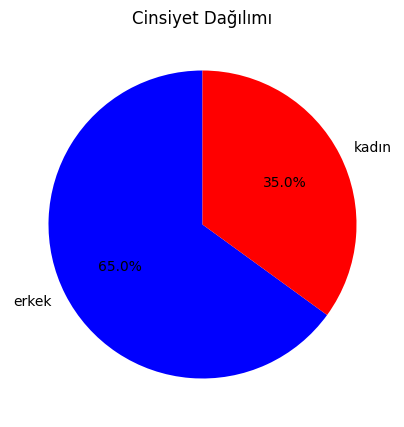

In [68]:
# cinsiyet dağılımının yüzdesel olarak görselleştirilmesi
plt.figure(figsize=(5,5))
plt.pie(cinsiyet_dagilimi, labels = cinsiyet_dagilimi.index,autopct="%1.1f%%",startangle=90,colors=["blue","red"])
plt.title("Cinsiyet Dağılımı")
plt.show()

### Histogram (Veri Dağılımı)
Sayısal değişkenlerin dağılımını incelemek için kullanırız

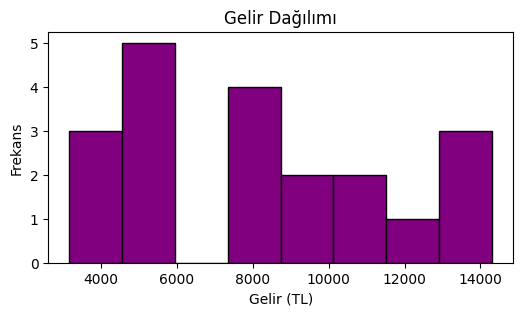

In [69]:
plt.figure(figsize=(6,3))
plt.hist(veri["gelir"],bins=8,color = "purple",edgecolor="black")
plt.title("Gelir Dağılımı")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()

### Kutu Grafiği (Box Plot)
İstatistiksel analiz ve outlier tespiti için kullanılır.

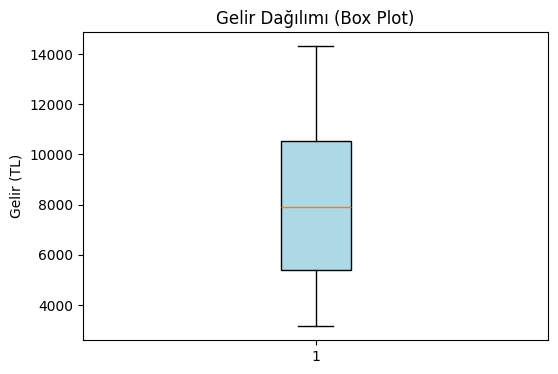

In [70]:
plt.figure(figsize=(6,4))
plt.boxplot(veri["gelir"],patch_artist=True,boxprops=dict(facecolor="lightblue"))
plt.title("Gelir Dağılımı (Box Plot)")
plt.ylabel("Gelir (TL)")
plt.show()

### Çoklu Grafik (Subplot)
Birden fazla değişkeni aynı anda yorumlamak için kullanırız.

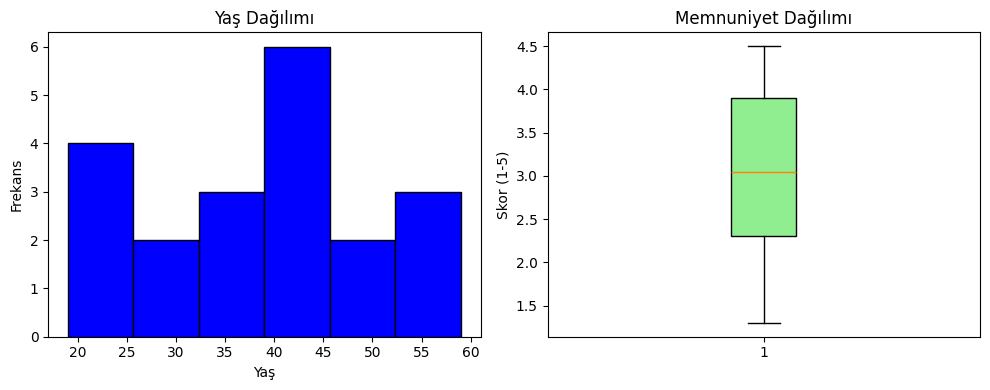

In [71]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
axs[0].hist(veri["yas"],bins=6,color="blue",edgecolor="black")
axs[0].set_title("Yaş Dağılımı")
axs[0].set_xlabel("Yaş")
axs[0].set_ylabel("Frekans")

axs[1].boxplot(veri["memnuniyet"],patch_artist=True,boxprops=dict(facecolor="lightgreen"))
axs[1].set_title("Memnuniyet Dağılımı")
axs[1].set_ylabel("Skor (1-5)")

plt.tight_layout()
plt.show()

Sonuç olarak;
* Matplotlib ile temel grafik türlerini oluşturmayı öğrendik
* Sayısal değişkenlerin dağılımını histogram ve boxplot ile yorumladık
* Kategorik değişkenleri bar ve pie chart ile karşılaştırdık
* Çoklu grafikler ile birden fazla chart ile aynı anda analiz yaptık.

## Görselleştirme: Seaborn
Seaborn kütüphanesi kullanarak hem istatistiksel hem de estetik açıdan güçlü grafikler oluşturmayı öğreneceğiz. Matplotlib ile temel çizim mantığını kavramıştık, şimdi seaborn ile veriyi daha yorumlanabilir, tematik ve istatistiksel açıdan anlamlı şekilde görselleştirelim.
* Sayısal veriler için: hisplot,kdeplot, boxplot, violinplot
* Kategorik veriler için: countplot, barplot, stripplot, swarmplot
* İlişki gösteren grafikler: scatterplot, lineplot, regplot, pairplot
* Korelasyon analizleri: heatmap, clustermap, jointplot
* Çoklu görselleştirme: facegrid, catplot, relplot

### Sayısal veriler için dağılım grafikleri

In [72]:
import seaborn as sns

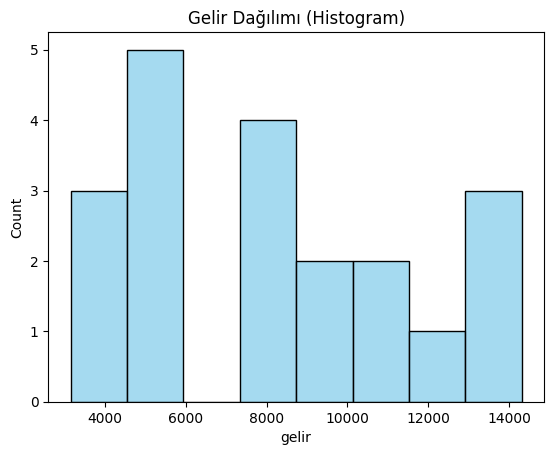

In [73]:
#histogram
sns.histplot(data =veri, x="gelir",bins=8,kde=False,color="skyblue")
plt.title("Gelir Dağılımı (Histogram)")
plt.show()

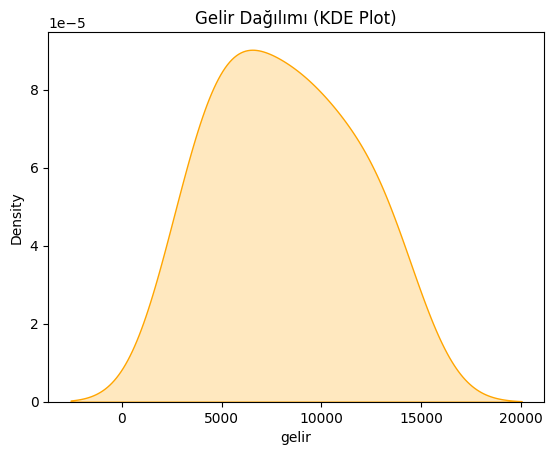

In [75]:
#kernel density estimation (yoğunluk eğrisi)
sns.kdeplot(data=veri,x="gelir",fill=True,color="orange")
plt.title("Gelir Dağılımı (KDE Plot)")
plt.show()

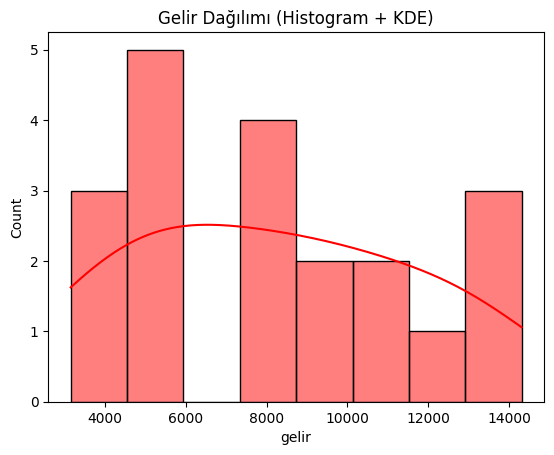

In [76]:
#histogram + kde
sns.histplot(data=veri,x="gelir",bins=8,kde=True,color="red")
plt.title("Gelir Dağılımı (Histogram + KDE)")
plt.show()

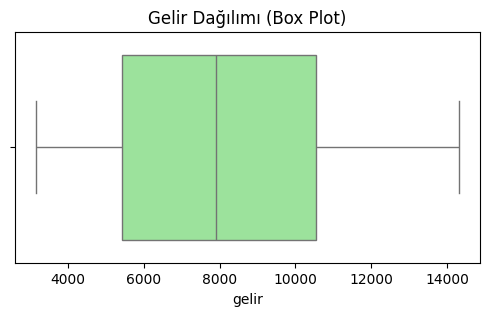

In [78]:
#boxplot
plt.figure(figsize=(6,3))
sns.boxplot(data=veri,x="gelir",color="lightgreen")
plt.title("Gelir Dağılımı (Box Plot)")
plt.show()

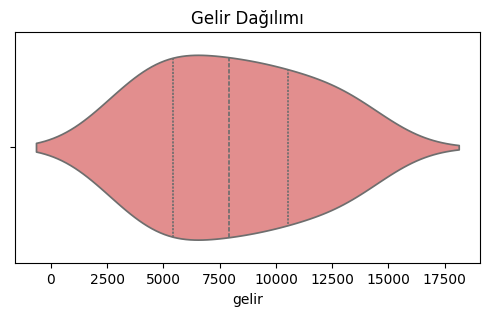

In [79]:
#violing plot (dağılım ve yoğunluğu)
plt.figure(figsize=(6,3))
sns.violinplot(data=veri,x="gelir",inner="quartile",color="lightcoral")
plt.title("Gelir Dağılımı" )
plt.show()

### Kategorik Değişkenler

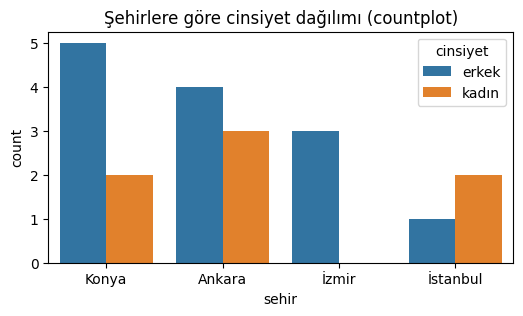

In [81]:
#countplot - kategorilerin frekansını gösterir
plt.figure(figsize=(6,3))
sns.countplot(data=veri,x="sehir",hue="cinsiyet")
plt.title("Şehirlere göre cinsiyet dağılımı (countplot)")
plt.show()

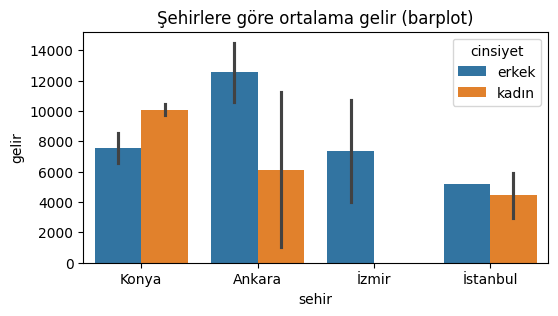

In [84]:
#barplot - kategorilere göre ortalama veya toplam değer
plt.figure(figsize=(6,3))
sns.barplot(data=veri,x="sehir",y="gelir",hue="cinsiyet",errorbar="sd")
plt.title("Şehirlere göre ortalama gelir (barplot)")
plt.show()

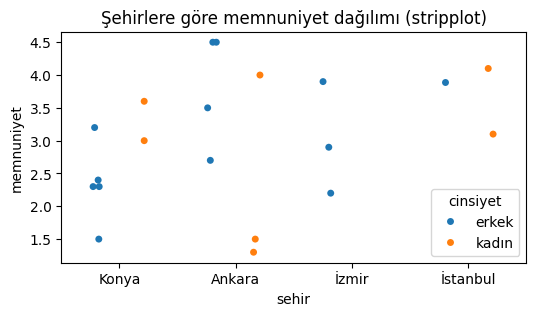

In [88]:
#strip plot - tek tek noktaları gösterir
plt.figure(figsize=(6,3))
sns.stripplot(data=veri,x ="sehir",y="memnuniyet",hue="cinsiyet",jitter=True,dodge=True)
plt.title("Şehirlere göre memnuniyet dağılımı (stripplot)")
plt.show()

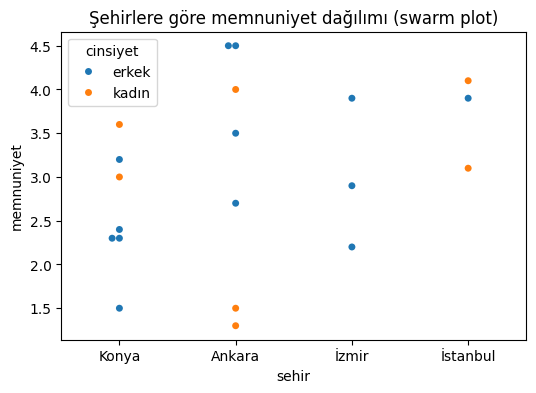

In [89]:
#swarm plot - noktalar çakışmadan yerleştirme (yoğunluk gösterir)
plt.figure(figsize=(6,4))
sns.swarmplot(data=veri,x="sehir",y="memnuniyet",hue="cinsiyet")
plt.title("Şehirlere göre memnuniyet dağılımı (swarm plot)")
plt.show()